# Импорт пакетов

In [279]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# Дополнительные функции для расчетов

In [280]:
def months_between(date1, date2):
    """
    Вычисляет количество месяцев между двумя датами.
    Предполагается, что день всегда равен 1.
    """
    # Убеждаемся, что date1 <= date2
    if date1 > date2:
        date1, date2 = date2, date1

    total_months = (date2.year - date1.year) * 12 + (date2.month - date1.month)

    return total_months

# Загрузка данных

In [281]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (127, 2)
Покупки:  (4728, 5)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


# Подготавливаем данные

In [282]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date   qty  delta  year  month  quarter
0   2016-01-01   849    0.0  2016      1        1
1   2016-02-01   848   -1.0  2016      2        1
2   2016-03-01   848    0.0  2016      3        1
3   2016-04-01   849    1.0  2016      4        2
4   2016-05-01   849    0.0  2016      5        2
..         ...   ...    ...   ...    ...      ...
122 2026-03-01  1020   11.0  2026      3        1
123 2026-04-01  1008  -12.0  2026      4        2
124 2026-05-01  1001   -7.0  2026      5        2
125 2026-06-01  1008    7.0  2026      6        2
126 2026-07-01  1007   -1.0  2026      7        3

[127 rows x 6 columns]


In [290]:
## Покупки
dataMonitor = (
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    .interpolate(method='linear')
    .assign(
        avg_price = lambda x: x["sum"] / x["data_qty"],
        sum_lag1 = lambda x: x["sum"].shift(1),
        sum_lag2 = lambda x: x["sum"].shift(2),
        sum_lag12 = lambda x: x["sum"].shift(12),
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        sum_avg6 = lambda x: x["sum"].rolling(window=6, min_periods=1).mean(),
        sum_avg12 = lambda x: x["sum"].rolling(window=12, min_periods=1).mean(),
        # Преобразуем месяц в радианы (2*pi соответствует полному кругу года)
        month_sin = lambda x: np.sin(2 * np.pi * x['month'] / 12),
        month_cos = lambda x: np.cos(2 * np.pi * x['month'] / 12)
    )
    .assign(
        avg_price_lag1 = lambda x: x["avg_price"].shift(1),
    )
    .ffill()
    .bfill()
    .fillna(0)
)

#dataMonitor = dataMonitor[dataMonitor["year"] >= 2022]

print(dataMonitor)

          date  data_qty        sum   qty  delta  year  month  quarter  \
0   2016-01-01       1.0    9016.95   849    0.0  2016      1        1   
1   2016-02-01       1.0    9016.95   848   -1.0  2016      2        1   
2   2016-03-01       1.0    9016.95   848    0.0  2016      3        1   
3   2016-04-01       1.0    9016.95   849    1.0  2016      4        2   
4   2016-05-01       1.0    9016.95   849    0.0  2016      5        2   
..         ...       ...        ...   ...    ...   ...    ...      ...   
122 2026-03-01       5.0   63770.50  1020   11.0  2026      3        1   
123 2026-04-01       6.0   59972.15  1008  -12.0  2026      4        2   
124 2026-05-01       6.0   67738.51  1001   -7.0  2026      5        2   
125 2026-06-01       6.0   74852.46  1008    7.0  2026      6        2   
126 2026-07-01      12.0  141147.60  1007   -1.0  2026      7        3   

        avg_price   sum_lag1    sum_lag2  sum_lag12       sum_avg3  \
0     9016.950000    9016.95    9016.950 

# Исследование

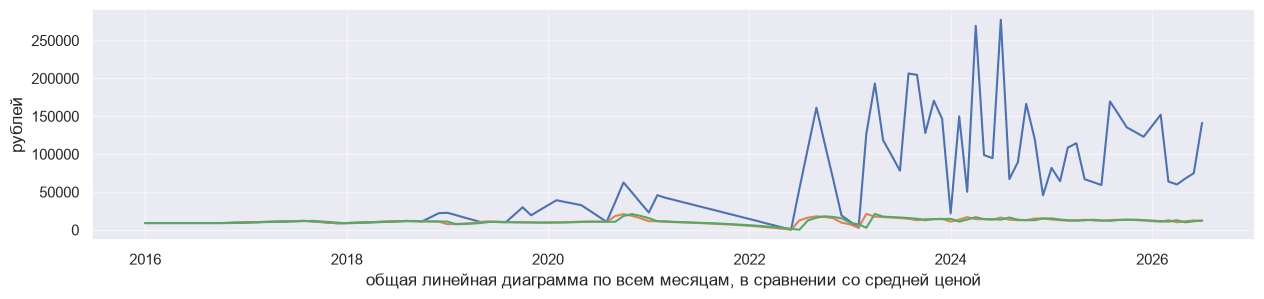

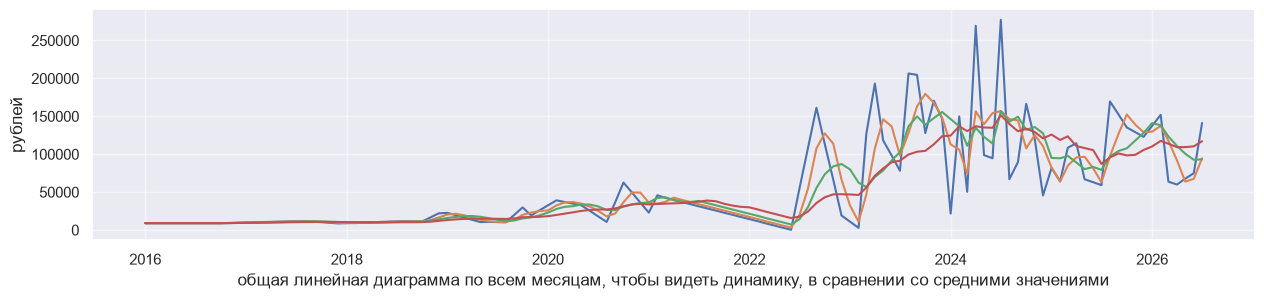

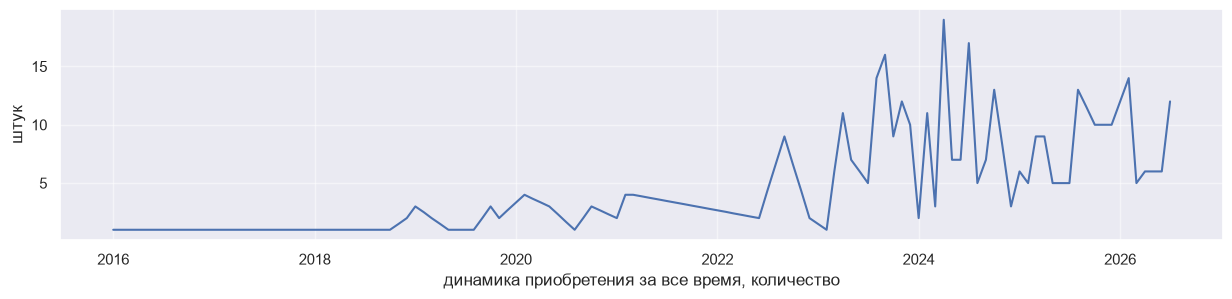

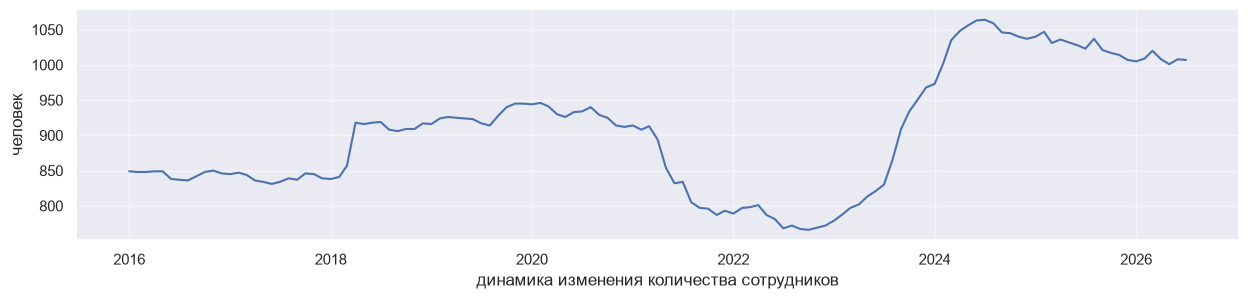

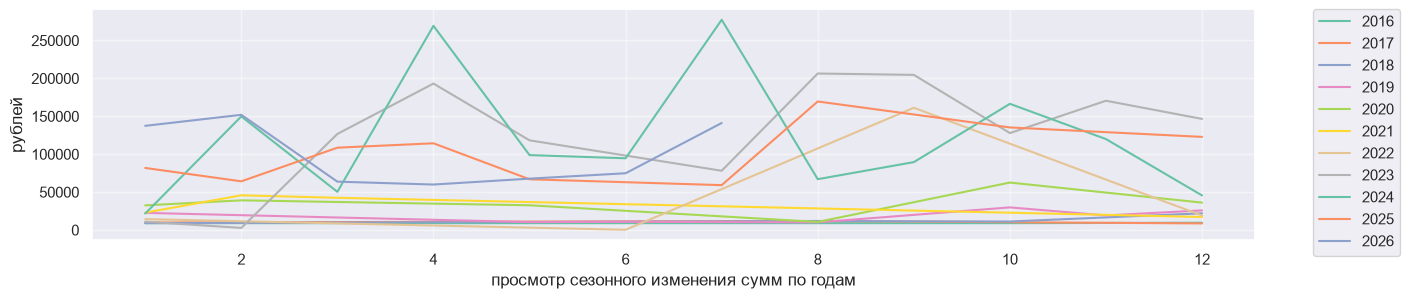

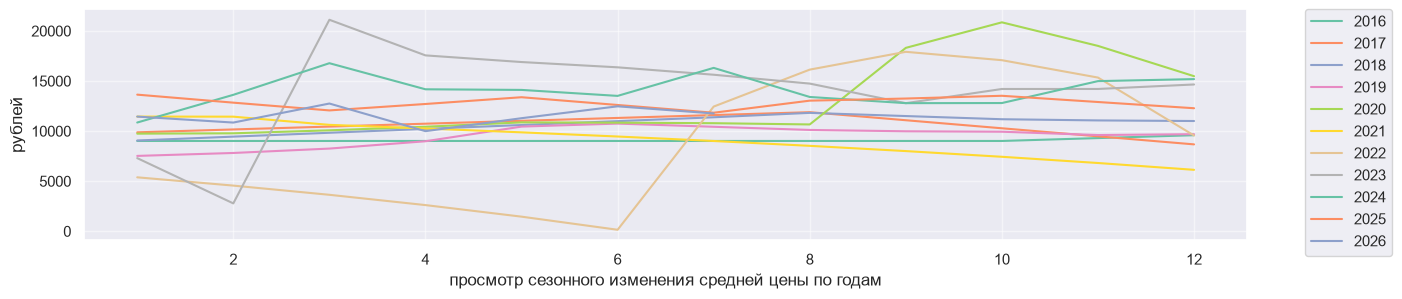

In [292]:
# общая линейная диаграмма по всем месяцам, чтобы видеть динамику, в сравнении со средней ценой
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="sum")
sns.lineplot(data=dataMonitor, x="date", y="avg_price")
plt.xlabel("общая линейная диаграмма по всем месяцам, в сравнении со средней ценой")
plt.ylabel("рублей")
plt.show()

# общая линейная диаграмма по всем месяцам, чтобы видеть динамику, в сравнении со средними значениями
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="sum")
sns.lineplot(data=dataMonitor, x="date", y="sum_avg3")
sns.lineplot(data=dataMonitor, x="date", y="sum_avg6")
sns.lineplot(data=dataMonitor, x="date", y="sum_avg12")
plt.xlabel("общая линейная диаграмма по всем месяцам, чтобы видеть динамику, в сравнении со средними значениями")
plt.ylabel("рублей")
plt.show()

# динамика приобретения за все время, количество
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="data_qty")
plt.xlabel("динамика приобретения за все время, количество")
plt.ylabel("штук")
plt.show()

# динамика изменения количества сотрудников
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="date", y="qty")
plt.xlabel("динамика изменения количества сотрудников")
plt.ylabel("человек")
plt.show()

# просмотр сезонного изменения сумм по годам
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor.sort_values("year"), x="month", y="sum", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения сумм по годам")
plt.ylabel("рублей")
plt.show()

# просмотр сезонного изменения средней цены по годам
plt.figure(figsize = (15,3))
sns.lineplot(data=dataMonitor, x="month", y="avg_price", hue="year", palette="Set2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xlabel("просмотр сезонного изменения средней цены по годам")
plt.ylabel("рублей")
plt.show()


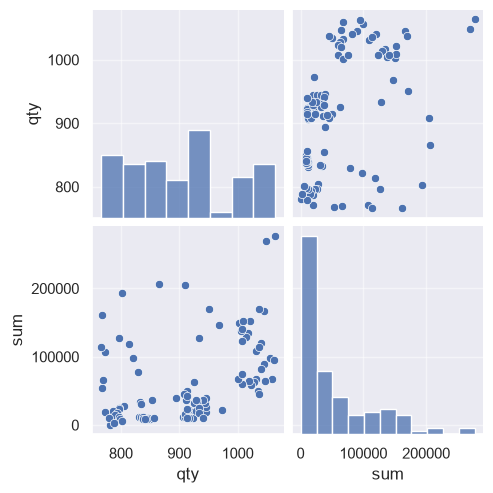

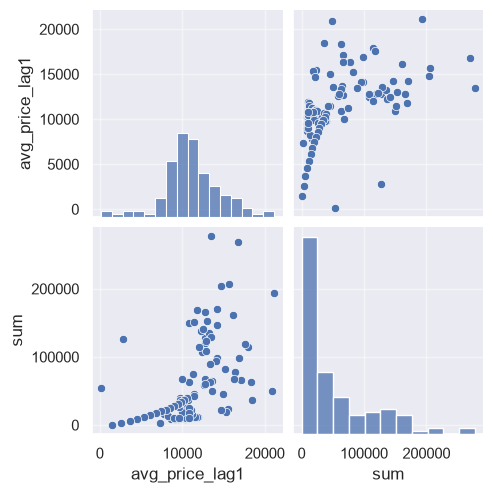

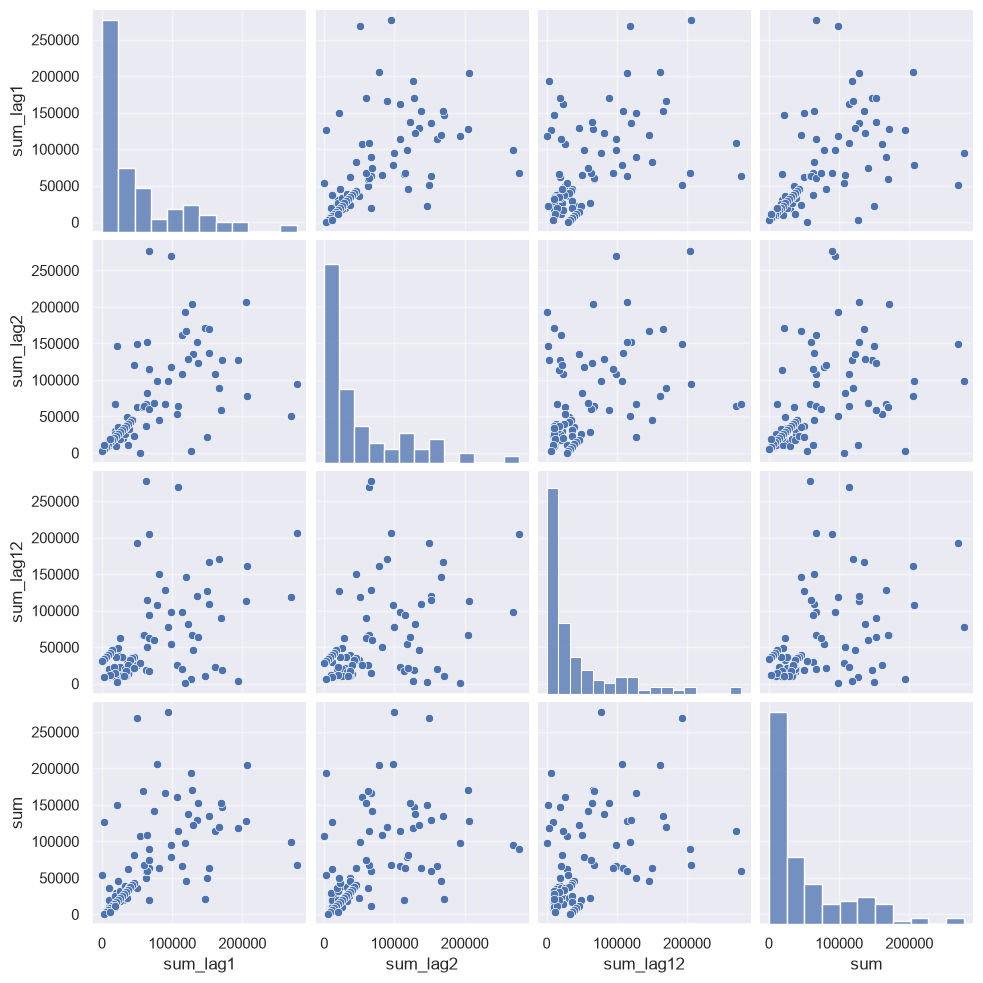

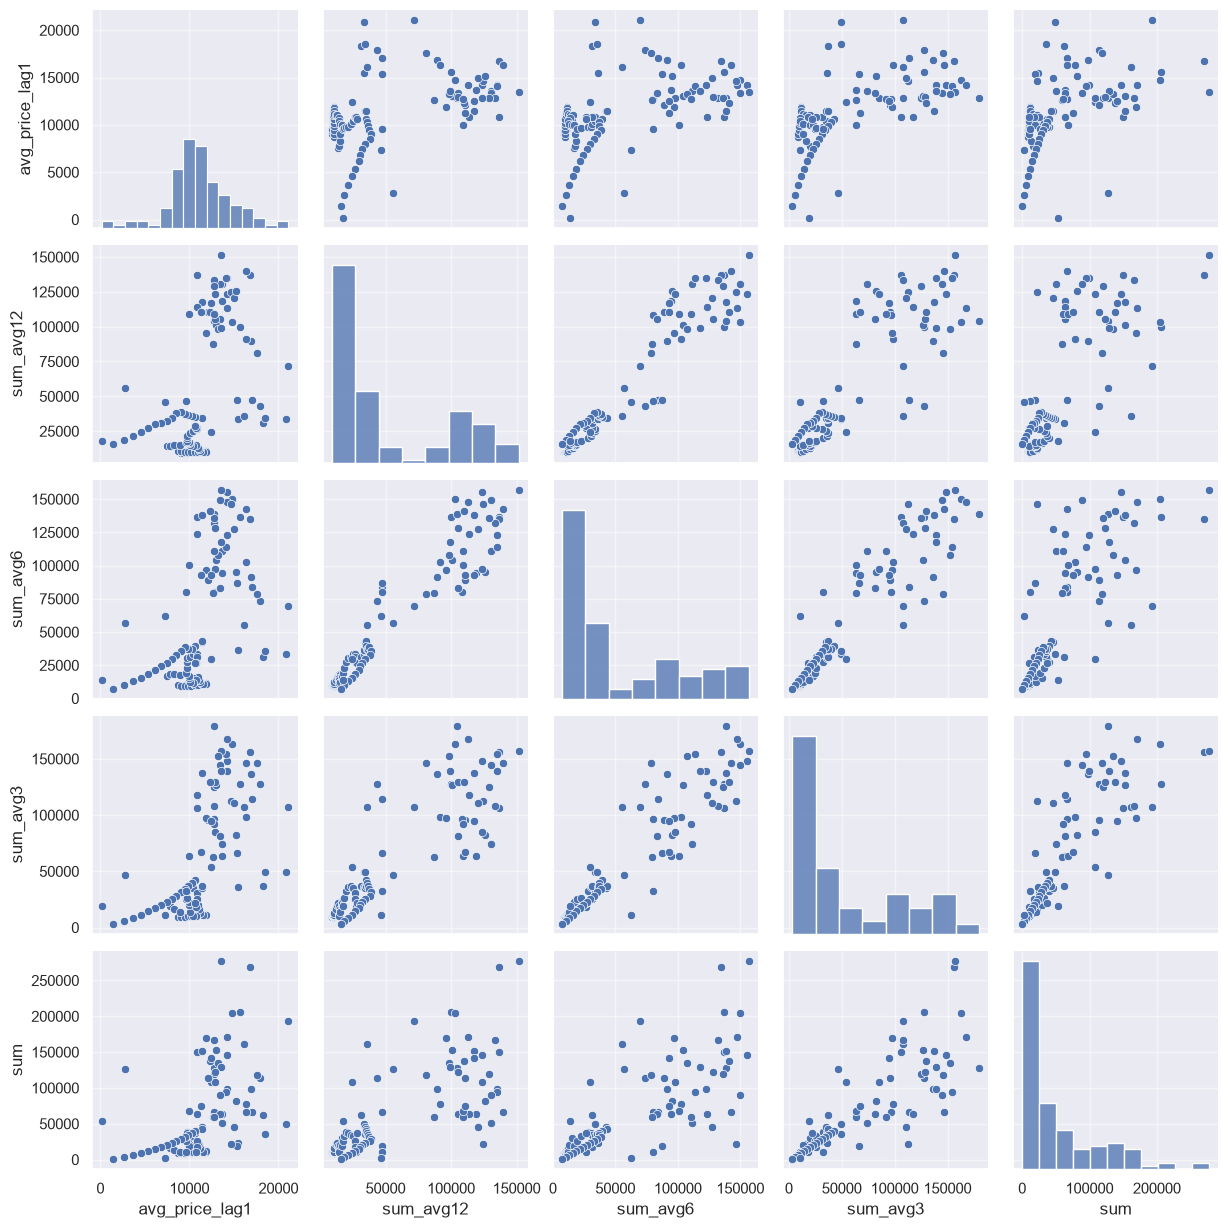

In [297]:
sns.pairplot(dataMonitor[["qty", "sum"]])
plt.show()

sns.pairplot(dataMonitor[["avg_price_lag1", "sum"]])
plt.show()

sns.pairplot(dataMonitor[["sum_lag1", "sum_lag2", "sum_lag12", "sum"]])
plt.show()


sns.pairplot(dataMonitor[["avg_price_lag1", "sum_avg12", "sum_avg6", "sum_avg3", "sum"]])
plt.show()


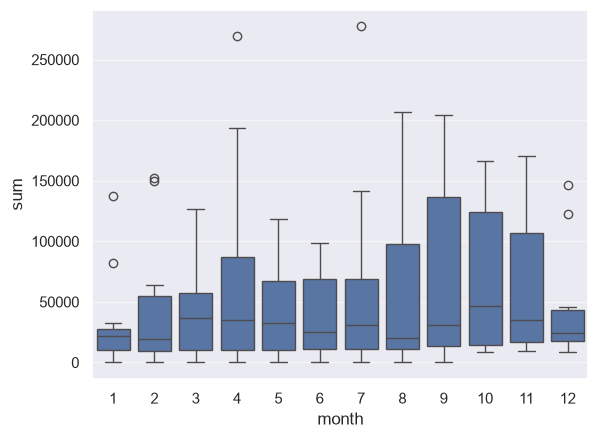

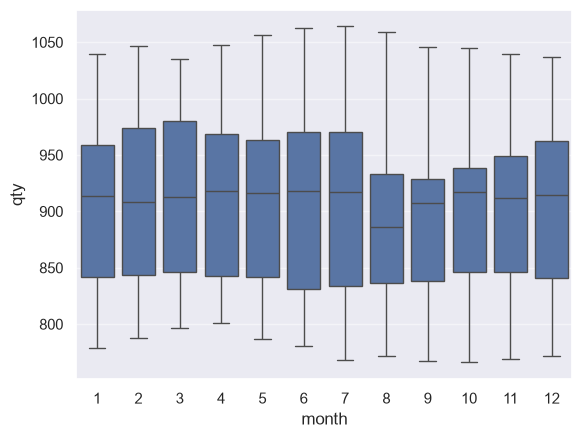

In [286]:
sns.boxplot(data =dataMonitor, x="month", y = "sum")
plt.show()

sns.boxplot(data =dataMonitor, x="month", y = "qty")
plt.show()

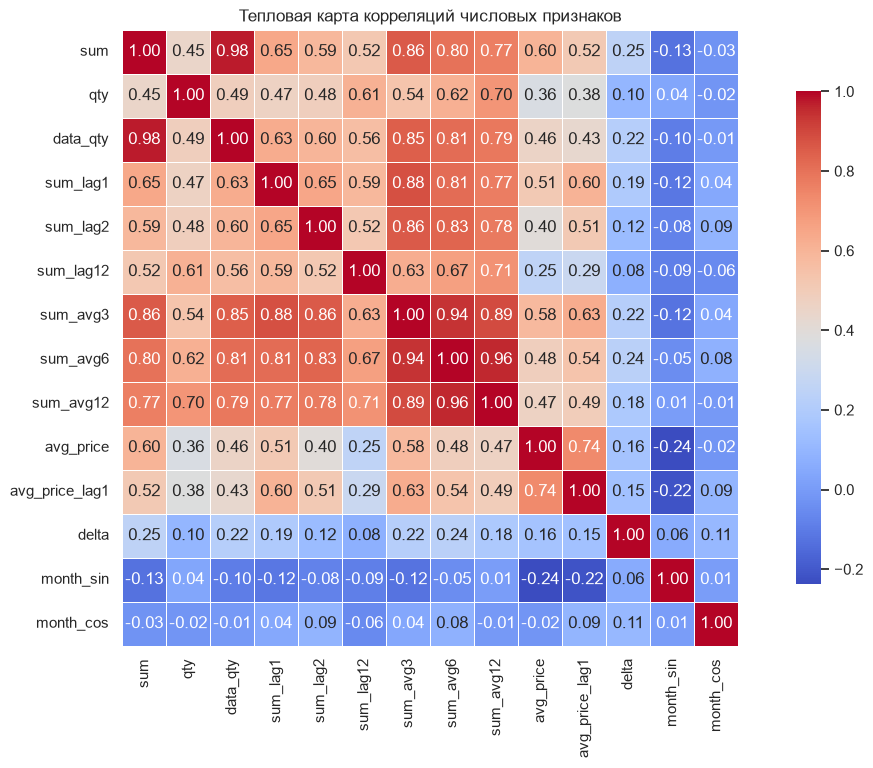

Корреляция по сумме
sum               1.000000
data_qty          0.975648
sum_avg3          0.858528
sum_avg6          0.799318
sum_avg12         0.766287
sum_lag1          0.645037
avg_price         0.599041
sum_lag2          0.585081
sum_lag12         0.517401
avg_price_lag1    0.516208
qty               0.447963
delta             0.248192
month_cos        -0.025207
month_sin        -0.130640
Name: sum, dtype: float64
Корреляция по количеству
data_qty          1.000000
sum               0.975648
sum_avg3          0.848973
sum_avg6          0.814828
sum_avg12         0.786324
sum_lag1          0.631586
sum_lag2          0.598122
sum_lag12         0.561009
qty               0.487367
avg_price         0.457363
avg_price_lag1    0.430382
delta             0.217905
month_cos        -0.009569
month_sin        -0.096109
Name: data_qty, dtype: float64
Корреляция по сотрудникам
qty               1.000000
sum_avg12         0.700905
sum_avg6          0.616534
sum_lag12         0.608716
sum_avg3

In [295]:
numeric_cols = ['sum', 'qty', 'data_qty',
                'sum_lag1', 'sum_lag2', 'sum_lag12',
                'sum_avg3', 'sum_avg6', 'sum_avg12', 'avg_price', 'avg_price_lag1', 'delta', 'month_sin', 'month_cos']
df_numeric = dataMonitor[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(15, 8))  # размер графика
sns.heatmap(corr_matrix,
            annot=True,        # показывать значения коэффициентов в ячейках
            fmt='.2f',         # формат чисел (2 знака после запятой)
            cmap='coolwarm',   # цветовая схема: синий – отрицательная, красный – положительная
            square=True,       # квадратные ячейки
            linewidths=0.5,    # линии между ячейками
            cbar_kws={"shrink": 0.8})  # настройка цветовой шкалы
plt.title('Тепловая карта корреляций числовых признаков')
plt.show()

print("Корреляция по сумме")
print(corr_matrix['sum'].sort_values(ascending=False))

print("Корреляция по количеству")
print(corr_matrix['data_qty'].sort_values(ascending=False))

print("Корреляция по сотрудникам")
print(corr_matrix['qty'].sort_values(ascending=False))

print("Корреляция по средней цене")
print(corr_matrix['avg_price'].sort_values(ascending=False))




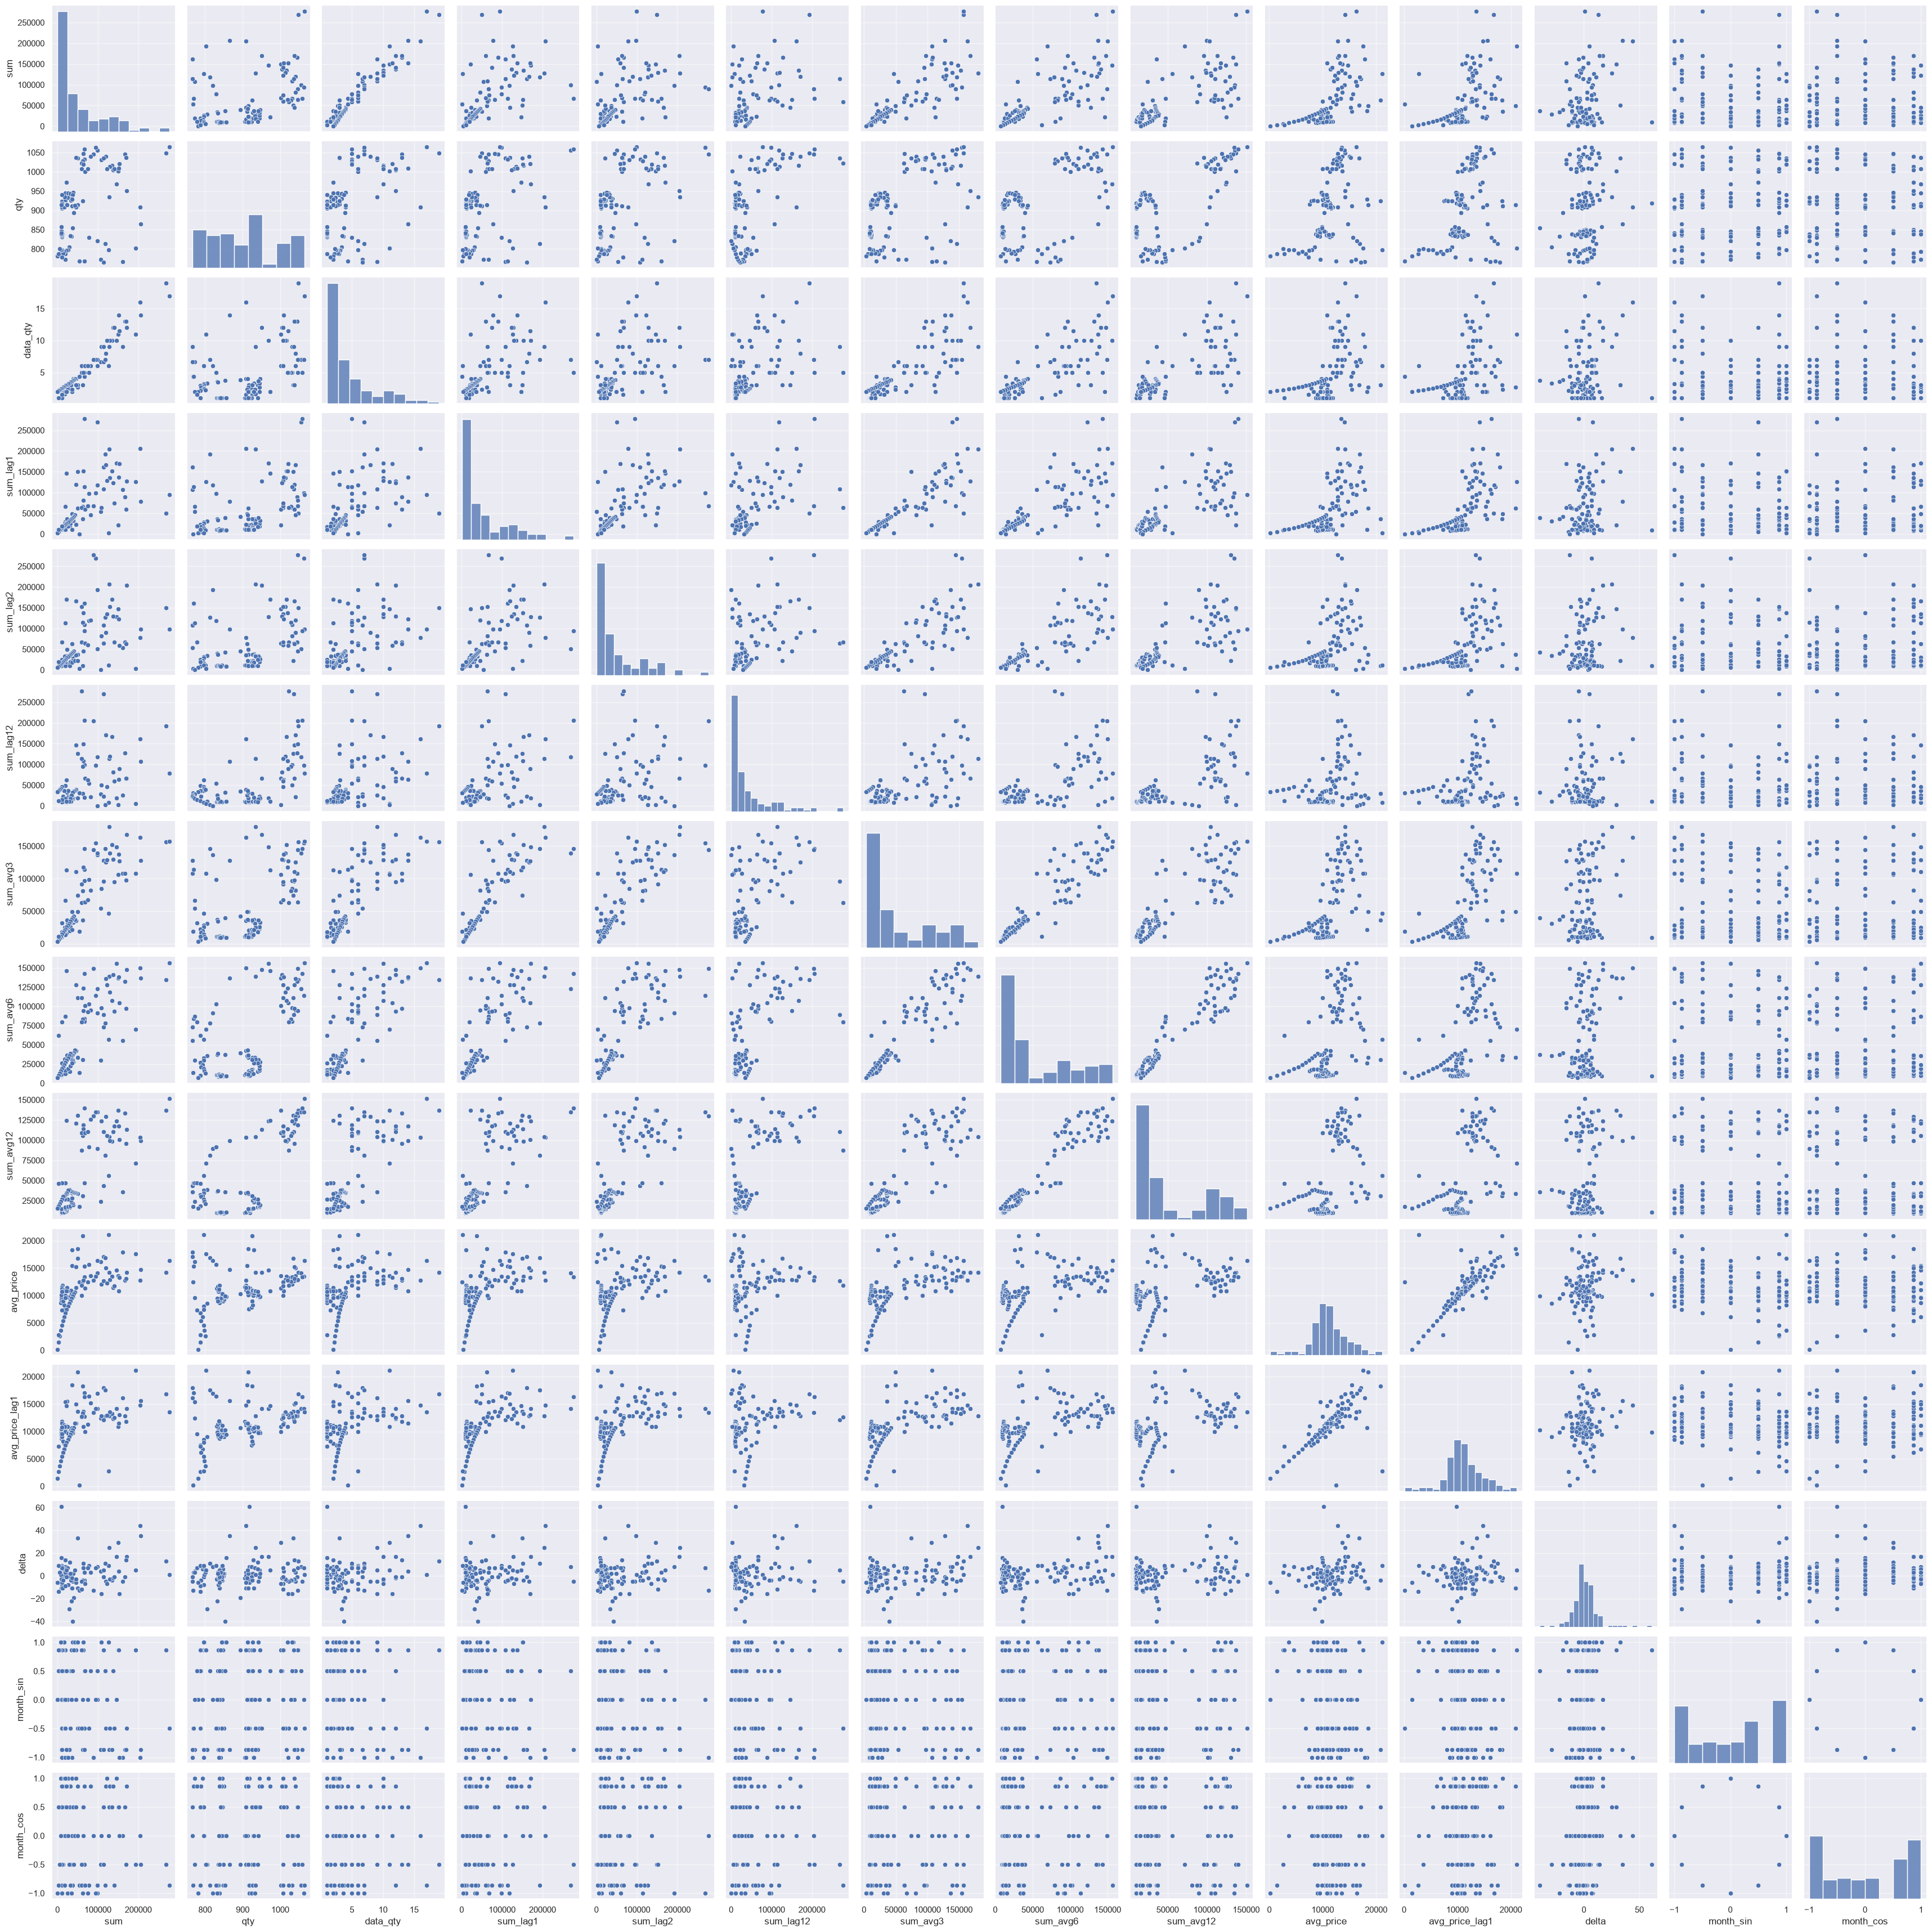

In [296]:
sns.pairplot(df_numeric)
plt.show()